1) markvlovitz
2) black letterman
3) risk parity (erc, naive, hierachy)

In [1]:
from helper import get_matrices, get_ticker_expected, plot_efficient_frontier, get_market_caps, get_black_litterman, get_full_portfolio_df
from finbert import ai_bl_params
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


/Users/sjegoh/Documents/GitHub/NUSSIF/Portfolio-Optimizer/venv_optimizer/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-08 17:24:09.149 No runtime found, using MemoryCacheStorageManager


In [2]:
basket = ["NVDA", "PG", "XLE", "TLT"]
start_date = "2024-01-01"


In [3]:
cv, _ = get_matrices(basket, start_date = start_date)


In [4]:
stats = get_ticker_expected(basket, start_date = start_date)
stats


,Expected Return,Volatility
NVDA,0.603911,0.499780
PG,0.014957,0.175305
XLE,0.133647,0.217619
TLT,-0.048816,0.128771


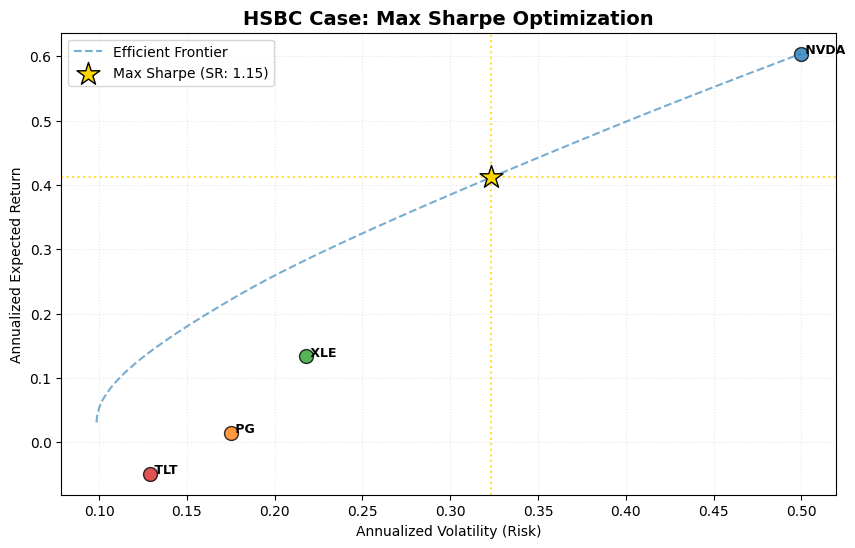

In [5]:
fig, weights = plot_efficient_frontier(stats, cv, basket, find_max_sharpe = True)
plt.show()


In [6]:
weights


NVDA    0.619764
PG      0.112373
XLE     0.267863
TLT     0.000000
Name: Optimal weights, dtype: float64

# Black Litterman
Need additional expected mu, conviction 

In [7]:
views_dict, conf_dict = ai_bl_params(basket)
market_caps = get_market_caps(basket)
market_caps


2026-03-08 17:24:12.369 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 32880.46it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 17:24:15.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 49350.53it/s]
BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-fls
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from differe

NVDA    4.321026e+12
PG      3.570362e+11
XLE     3.850428e+10
TLT     4.435384e+10
Name: Market_Cap, dtype: float64

In [8]:
final_views = {}
for ticker in basket:
    m_ret = stats["Expected Return"][ticker]
    n_ret = views_dict[ticker]
    
    combined = (m_ret + n_ret)
    final_views[ticker] = combined


In [9]:
market_caps


NVDA    4.321026e+12
PG      3.570362e+11
XLE     3.850428e+10
TLT     4.435384e+10
Name: Market_Cap, dtype: float64

In [10]:
final_views


{'NVDA': np.float64(0.609719226359382),
 'PG': np.float64(0.04502146263942983),
 'XLE': np.float64(0.12395705434608899),
 'TLT': np.float64(0.03180456869410366)}

In [11]:
stats


,Expected Return,Volatility
NVDA,0.603911,0.499780
PG,0.014957,0.175305
XLE,0.133647,0.217619
TLT,-0.048816,0.128771


In [12]:
bl_mu = get_black_litterman(
    cov_matrix=cv,          # Your covariance matrix
    mcaps=market_caps,            # Your Series of market caps
    views_dict=final_views,  # The {Ticker: Return} dict
    conf_dict=conf_dict,    # The {Ticker: Confidence} dict
    delta=5.0,              # Risk aversion
    tau=0.5                # Conviction of conviction
)

bl_mu

bl_df = stats.copy()
bl_df["Expected Return"] = bl_mu


In [23]:
print(stats)
print(bl_df)


      Expected Return  Volatility
NVDA         0.603911    0.499780
PG           0.014957    0.175305
XLE          0.133647    0.217619
TLT         -0.048816    0.128771
      Expected Return  Volatility
NVDA         0.542486    0.499780
PG           0.026814    0.175305
XLE          0.116652    0.217619
TLT          0.021602    0.128771


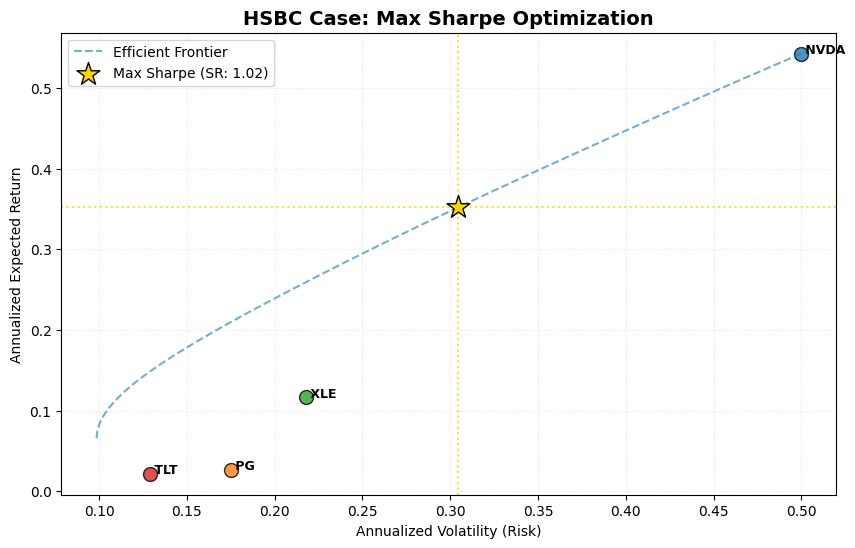

In [13]:
fig, weights = plot_efficient_frontier(bl_df, cv, basket, find_max_sharpe = True)
plt.show()


In [14]:
weights


NVDA    5.959530e-01
PG      2.073461e-01
XLE     1.967009e-01
TLT     1.035413e-17
Name: Optimal weights, dtype: float64

In [15]:
from pypfopt import HRPOpt

price_data = get_full_portfolio_df(basket, start_date = start_date)

def run_hrp_optimization(price_data):
    # 1. Calculate historical returns for the correlation matrix
    returns = price_data.pct_change().dropna()
    
    # 2. Initialize HRP
    hrp = HRPOpt(returns)
    
    # 3. Optimize the weights
    # HRP does not need 'Expected Returns' - it only needs the returns' structure
    weights = hrp.optimize()
    
    # 4. Clean and return
    cleaned_weights = hrp.clean_weights()
    return pd.Series(cleaned_weights)



Fetching data for NVDA...
Fetching data for PG...
Fetching data for XLE...
Fetching data for TLT...


In [16]:
cleaned_hrp = run_hrp_optimization(price_data)
hrp_weights = np.array([cleaned_hrp[t] for t in price_data.columns])


# Portfolio Volatility (Standard Deviation)
hrp_ret = np.dot(hrp_weights, stats["Expected Return"].values)

# 2. Precision Volatility (Requires your cov_matrix)
hrp_vol = np.sqrt(np.dot(hrp_weights.T, np.dot(cv.values, hrp_weights)))

hrp_sharpe = (hrp_ret - 0.02) / hrp_vol
print(f"HRP Sharpe Ratio: {hrp_sharpe:.2f}")


HRP Sharpe Ratio: 0.06


In [17]:
hrp_ret


np.float64(0.026060178882984564)

In [18]:
hrp_vol


np.float64(0.09906733863783863)

In [19]:
from pypfopt import EfficientCVaR, expected_returns

def run_cvar_optimization(price_data, alpha=0.95):
    """
    Optimizes for the Minimum CVaR (Expected Shortfall).
    alpha=0.95 means we are looking at the average of the worst 5% of losses.
    """
    # 1. Calculate daily returns (CVaR needs the raw distribution, not a matrix)
    returns = price_data.pct_change().dropna()
    
    # 2. Initialize EfficientCVaR 
    # We pass 'None' for expected returns to focus purely on risk minimization
    # beta is the confidence level (0.95 corresponds to the 5% tail)
    ec = EfficientCVaR(expected_returns=None, returns=returns, beta=alpha)
    
    # 3. Optimize for the minimum CVaR
    weights = ec.min_cvar()
    
    # 4. Clean and return as a Series
    cleaned_weights = ec.clean_weights()
    return pd.Series(cleaned_weights.values(), index=returns.columns)




In [20]:
cleaned_cvar = run_cvar_optimization(price_data)
cleaned_cvar


NVDA    0.08287
PG      0.25207
XLE     0.12361
TLT     0.54145
dtype: float64

In [21]:
cleaned_cvar = run_cvar_optimization(price_data)
cvar_weights = np.array([cleaned_cvar[t] for t in price_data.columns])

# Portfolio Volatility (Standard Deviation)
cvar_ret = np.dot(cvar_weights, stats["Expected Return"].values)

# 2. Precision Volatility (Requires your cov_matrix)
cvar_vol = np.sqrt(np.dot(cvar_weights.T, np.dot(cv.values, cvar_weights)))

cvar_sharpe = (cvar_ret - 0.02) / cvar_vol
print(f"CVAR Sharpe Ratio: {cvar_sharpe:.2f}\nCVAR Ret: {cvar_ret:.2f}\nCVAR Vol: {cvar_vol:.2f}")


CVAR Sharpe Ratio: 0.24
CVAR Ret: 0.04
CVAR Vol: 0.10


In [22]:
print(f"CVAR Sharpe Ratio: {cvar_sharpe:.2f}\nCVAR Ret: {cvar_ret:.2f}\nCVAR Vol: {cvar_vol:.2f}")
print(f"HRP Sharpe Ratio: {hrp_sharpe:.2f}\nHRP Ret: {hrp_ret:.2f}\nHRP Vol: {hrp_vol:.2f}")


CVAR Sharpe Ratio: 0.24
CVAR Ret: 0.04
CVAR Vol: 0.10
HRP Sharpe Ratio: 0.06
HRP Ret: 0.03
HRP Vol: 0.10
